# Target Definition and Exploratory Analysis

This notebook defines and evaluates the binary classification target for the hospital excess readmission project. The goal is to determine whether the excess readmission ratio threshold is reasonable and whether the target classes are balanced enough for modeling.

## Load Filtered Analytical Dataset

The filtered dataset containing valid excess readmission ratio records is loaded from the processed data folder. The dataset shape and first few rows are inspected to confirm the structure before exploratory analysis begins.

In [ ]:
#Import pandas for loading in data
import pandas as pd

#Load processed dataset containing valid ERR records
df_valid_err = pd.read_parquet("../data/processed/valid_err.parquet")

#Confirm dataset dimensions after loading
df_valid_err.shape

df_valid_err.head()

## Preliminary Structural Exploration

Before defining the modeling target, I inspect the structure of the filtered dataset to better understand hospital-measure representation and reporting patterns.

This includes checking how many measure records each hospital contains, reviewing the distribution of reported readmission counts, and inspecting whether certain measure categories contain different reporting behavior.

In [ ]:
# Check how many measure records each hospital contains
# after filtering valid ERR rows
df_valid_err.groupby('facility_id')['measure_name'].count()

# Inspect unique values inside number_of_readmissions
# to identify suppressed/non-numeric reporting values
df_valid_err['number_of_readmissions'].value_counts()

# Inspect readmission count distributions by measure category
df_valid_err.groupby('measure_name')['number_of_readmissions'].value_counts()

#Inspect how target classes are distributed across measure categories
df_valid_err.groupby(df_valid_err['excess_readmission_ratio'] > 1)['measure_name'].value_counts()

## Excess Readmission Ratio Distribution

Before creating the binary classification target, I inspect the numerical distribution of excess readmission ratio values using summary statistics.

This helps evaluate the spread, central tendency, and overall range of ERR values before threshold-based classification.

In [ ]:
# Numerical summary statistics for ERR distribution
df_valid_err['excess_readmission_ratio'].describe()

## ERR Distribution Visualization

A histogram and KDE plot are used to visualize the distribution of excess readmission ratio values.

The mean, median, and quartiles are added as reference lines to help evaluate how tightly the records cluster around the classification threshold.

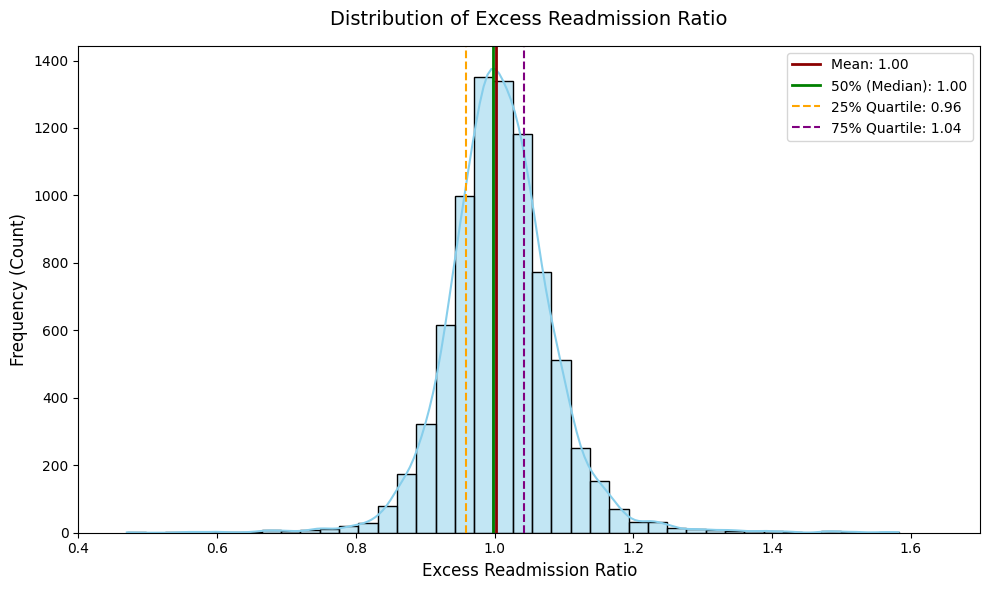

In [11]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure canvas
plt.figure(figsize=(10, 6))

# Plot histogram + KDE for ERR distribution
sns.histplot(df_valid_err['excess_readmission_ratio'], bins=40, kde=True, color='skyblue', edgecolor='black')

# Add statistical reference lines from describe() output
plt.axvline(1.001777, color='darkred', linestyle='-', linewidth=2, label='Mean: 1.00')
plt.axvline(0.997300, color='green', linestyle='-', linewidth=2, label='50% (Median): 1.00')
plt.axvline(0.958200, color='orange', linestyle='--', linewidth=1.5, label='25% Quartile: 0.96')
plt.axvline(1.042300, color='purple', linestyle='--', linewidth=1.5, label='75% Quartile: 1.04')

# Final chart formatting
plt.title('Distribution of Excess Readmission Ratio', fontsize=14, pad=15)
plt.xlabel('Excess Readmission Ratio', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)

# Set x-axis range based on observed ERR spread
plt.xlim(0.4, 1.7) 

# Show legend
plt.legend(loc='upper right')

# Prevent overlapping elements
plt.tight_layout()

# Display plot
plt.show()


## Distribution Interpretation

The ERR distribution is tightly centered around 1.0, meaning many records are close to the classification boundary.

This makes the classification problem more realistic but also more difficult, because relatively small differences in ERR values can place otherwise similar hospital-measure observations into opposite target classes.

## Feature Selection and Leakage Review

Before modeling, each column was reviewed for analytical usefulness and leakage risk. The final conservative feature set includes `state`, `measure_name`, and `number_of_discharges`.

`state` is included as a geographic/contextual feature. `measure_name` is included because different HRRP measure categories represent different clinical and operational reporting groups. `number_of_discharges` is included as an operational volume feature.

The leakage-related columns `excess_readmission_ratio`, `predicted_readmission_rate`, and `expected_readmission_rate` are excluded because the target is defined from ERR, and the rate columns are directly related to the ERR calculation. `facility_id` and `facility_name` are excluded because they are identifiers. `start_date` and `end_date` are excluded because they do not add useful variation. `footnote` and `number_of_readmissions` are excluded under a conservative modeling approach.

## Create Binary Target Variable

The binary target column is formally created using an ERR threshold of greater than 1.0.

Records with ERR values above 1.0 are classified as high excess readmission observations, while records at or below 1.0 are treated as the non-excess class.

In [ ]:
#Formally create the target column 
df_valid_err['high_excess_readmission'] = (
    df_valid_err['excess_readmission_ratio'] > 1
).astype(int)

## Remaining Missing Values in Number of Discharges

After filtering to valid ERR rows, `number_of_discharges` still contains missing values.

The remaining missing rows are reviewed by `measure_name` to evaluate whether the missingness is isolated to a specific HRRP measure category or distributed more broadly across the dataset.

In [ ]:
#Inspect remaining null values in number_of_discharges column
df_valid_err['number_of_discharges'].isna().sum()

#Inspect whether removing null values impacts the distribution of measure_name data
df_valid_err[df_valid_err['number_of_discharges'].isna()]['measure_name'].value_counts()

## Remove Rows Missing Number of Discharges

Rows with missing `number_of_discharges` values are removed before modeling because this column is retained as a modeling feature.

After removing these rows, the ERR distribution is rechecked to confirm that the overall target distribution remains broadly similar.

In [ ]:
#After validating that removing null values still kept the data consistent,
#drop the null values for modeling
df_valid_err = df_valid_err.dropna(subset = ['number_of_discharges'])

#Check if there are any remaining null values
df_valid_err.isna().sum()

#Reconfirm the distribution of data after removing null values
df_valid_err['excess_readmission_ratio'].describe()

## Construct Final Modeling Dataset

The final modeling dataframe is created using the selected feature columns and the binary target variable.

The data types are checked before export to confirm that the modeling dataset structure is valid for later machine learning workflows.

In [ ]:
#Confirm data types before creating final modeling dataframe
df_valid_err.dtypes

#Take the columns to be included and create a modeling ready dataframe
df_model_ready = df_valid_err[['state', 'measure_name',
                'number_of_discharges', 'high_excess_readmission']]

## Final Modeling Dataset

The final modeling dataset contains only the selected features and target variable:

- `state`
- `measure_name`
- `number_of_discharges`
- `high_excess_readmission`

The final data types were checked before export. `state` and `measure_name` are string/object fields, `number_of_discharges` is numeric (`float64`), and `high_excess_readmission` is binary integer (`int64`).

In [ ]:
#Check final dataframe structure before exporting
df_model_ready.head()

#Check final data types before exporting
df_model_ready.dtypes

## Export Final Modeling Dataset

The final modeling-ready dataframe is exported as a Parquet file so it can be loaded cleanly in the modeling notebook. This keeps the cleaning, EDA, and modeling phases separated across notebooks.

In [ ]:
#Export final modeling dataframe
df_model_ready.to_parquet('../data/processed/df_model_ready.parquet')